### Description of notebook

This notebook was developed by adapting a notebook from the MIMIC_Extract pipeline (notebooks/Baselines for Mortality and LOS prediction - Sklearn.ipynb).
Wang, S., McDermott, M.B.A., Chauhan, G., Ghassemi, M., Hughes, M.C. and Naumann, T. (2020) “MIMIC-Extract: A Data Extraction, Preprocessing, and Representation Pipeline for MIMIC-III,” ACM CHIL 2020 - Proceedings of the 2020 ACM Conference on Health, Inference, and Learning. Association for Computing Machinery, Inc, pp. 222–235. Available at: https://doi.org/10.1145/3368555.3384469.
https://github.com/MLforHealth/MIMIC_Extract

Numerous adaptations were made due to design differences compared to the MIMIC_Extract approach, including: use of the MIMIC IV dataset rather than MIMIC III; use of a PostgreSQL database for initial data processing; restriction to one outcome (length of stay > 7 days); defining the observation window to a 48 hour period with 24 hours before and after the admission to ICU; addition of the summary representation; and differences in missing data imputation strategy. The section reporting results is entirely new and not related to the MIMIC_Extract notebook.

In [2]:
import copy, math, os, pickle, time, pandas as pd, numpy as np, scipy.stats as ss, pathlib as pl, gc, pyarrow, tracemalloc

from pathlib import Path

from dotenv import load_dotenv

from matplotlib import pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score, roc_auc_score, accuracy_score, f1_score, confusion_matrix, brier_score_loss
from sklearn.calibration import CalibrationDisplay


In [ ]:
#GAP_TIME          = 6  # In hours.  I don't need this as there is already a gap between end of data and predicted outcome (at 7 days)
WINDOW_SIZE       = 49 # In hours.  For my project, this is 49 hours as I have 24 hours prior to ICU inttime, 24 hours in ICU.  
SEED              = 1
ID_COLS           = ['subject_id', 'hadm_id', 'icustay_id']
ID_COLS_HOURLY = ID_COLS + ['hours_in']
TESTING = False          # set False for the full cohort run
PROJECT_ROOT = Path.cwd().parents[0]   # adjust after checking Path.cwd()
load_dotenv()
BACKUP_ROOT = Path(os.environ["BACKUP_ROOT"])
FLAT_DATA_PATH = BACKUP_ROOT / 'results' / 'models' / 'flat_data.pkl'  # location to save the processed data (train/dev/test) for later model evaluation
PLOTS_DIR = PROJECT_ROOT / 'results'/ 'plots'
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables'
train_frac, dev_frac, test_frac = 0.7, 0.1, 0.2 

np.random.seed(SEED)
#torch.manual_seed(SEED)

In [ ]:
# Set up classes (from MIMIC_Extract)

class DictDist():
    def __init__(self, dict_of_rvs): self.dict_of_rvs = dict_of_rvs
    def rvs(self, n):
        a = {k: v.rvs(n) for k, v in self.dict_of_rvs.items()}
        out = []
        for i in range(n): out.append({k: vs[i] for k, vs in a.items()})
        return out
    
class Choice():
    def __init__(self, options): self.options = options
    def rvs(self, n): return [self.options[i] for i in ss.randint(0, len(self.options)).rvs(n)]

In [ ]:
# Connect to postgresql database (new)

import getpass
from sqlalchemy import create_engine

pg_user = 'postgres'      # same value you use to connect via psql
pg_host = 'localhost'          # or wherever your Postgres server is
pg_port = 5432
pg_dbname = 'mimiciv'

pg_password = getpass.getpass('Postgres password: ')

engine = create_engine(
    f'postgresql+psycopg2://{pg_user}:{pg_password}@{pg_host}:{pg_port}/{pg_dbname}'
)

### Processing of the datasets

The following cells create the datasets - these are saved as pickle files and can be picked up just before the 'sklearn' section

In [ ]:
%%time

# Read in hourly aggregated dataset (new)


hourly_table = 'msc_project.sample_hourly_data' if TESTING else 'msc_project.hourly_data'

hourly_query = f"SELECT * FROM {hourly_table}"

data_full_lvl2 = (
    pd.read_sql(hourly_query, engine)
    .set_index(ID_COLS_HOURLY)
    .drop(columns='hour_end')   # dropping hour_end as it is redundant - hours_in tracks time since admission.
    .astype('float32')              # data type should be float (dealing with potential for all missing values). 
                                    # can specify float32 rather than default float64 to reduce memory usage.
)

print(data_full_lvl2.shape)

(2540062, 30)
CPU times: total: 34.7 s
Wall time: 9min 10s


In [ ]:
%%time
# read in static data (new)

statics_table = 'msc_project.sample_allpatients' if TESTING else 'msc_project.allpatients'

statics_query = f"SELECT * FROM {statics_table}"

statics = pd.read_sql(statics_query, engine).set_index(ID_COLS)

print(statics.shape)

(51838, 12)
CPU times: total: 859 ms
Wall time: 3.3 s


In [ ]:
%%time

# read in the summary representation data (new)

alt_table = 'msc_project.sample_alternative_data' if TESTING else 'msc_project.alternative_data'

alt_query = f"SELECT * FROM {alt_table}"

data_full_alt = pd.read_sql(alt_query, engine)

print(data_full_alt.shape)

(1316988, 14)
CPU times: total: 19 s
Wall time: 3min 20s


### Imputer function

The following function simple_imputer() is adapted from the MIMIC-Extract function 'simple_imputer' in 'notebooks/Baselines for Mortality and LOS prediction - Sklearn.ipynb', which
deals with missing values in the hourly data. The original function takes a dataframe with a multi-index of 
(subject_id, hadm_id, icustay_id, hours_in) and columns with a multi-index of (label, LEVEL1, LEVEL2, 
Aggregation Function). The function fills in missing values for the 'mean' aggregation function using 
forward fill and the mean of the icustay, and creates a 'mask' column indicating whether the original value 
was present or not. It also calculates the time since the last measurement for each variable.

This adaptation takes a dataframe with only one column per variable for the mean per hour. This is indexed by 
the ID columns and hour. If there is no measurement in a given hour, it is supplied as NaN in the input. 

I have made a decision to forward fill the missing values, but not to fill missing values at the start with the 
mean for the stay. It seems incorrect to impute values for hours before the first measurement - I do not want to use measures from 
after the relevant time point to impute values for before the first measurement. Instead I am filling with the mean from the training
data standardization (zero) (this function will be run after standardization).

In [ ]:
""""
Simple imputer function adapted from the MIMIC_Extract function 'simple_imputer' in notebooks/Baselines for Mortality and LOS prediction - Sklearn.ipynb
"""

def simple_imputer(df, id_cols=ID_COLS):

    df = df.copy()
    # NB the forward fill depends on hours_in being in order for each stay.
    df = df.sort_index()    # Therefore sort. The index has been set earlier to be the ID_COLS + ['hours_in'] for the hourly data.

    mask = df.notna().astype(float)    # see later for why we convert to float. This is the mask of whether a 
                                        # measurement was present or not.
    imputed = (
        df.groupby(level=id_cols).ffill()              # forward fills from the last measurement.
        .fillna(0)                                      # otherwise, fills with zero (mean from training dataset, not the mean value for the stay)
    )

    # grouping by stay here, this will mean that the last observed time should be only within the stay, 
    # not across other stays as in the original notebook. 
    is_absent = 1 - mask                # This is now 1 if the measurement is absent, 0 if there is a measurement.
    total_hours_of_absence = is_absent.groupby(level=id_cols).cumsum()   # cumulative sum of hours with no measurement for the stay.
    absent_hours_before_last_measure = (
        total_hours_of_absence[is_absent == 0]
        .groupby(level=id_cols).ffill()   
    )   # This is the number of absent hours before the latest measurement. 
    hours_since_last_measure = (total_hours_of_absence - absent_hours_before_last_measure).fillna(100)  # 100 is beyond the maximum hours covered in my data.

    df_out = pd.concat(
        [imputed, mask, hours_since_last_measure],             # temporary - include all of the measures to review progress. 
        axis = 1,
        keys = ['mean', 'mask', 'hours_since_last_measure']     # rename imputed as mean to match the MIMIC_Extract code.
    )

    # Carrying out renaming and restructuring here to work with later code from MIMIC_Extract.
    df_out.columns.names = ['Aggregation Function', 'variable']     # need top level names
    df_out = df_out.swaplevel(0, 1, axis=1)                           # swap levels so variable is top level, aggregation next, to match MIMIC_Extract pipeline.
    df_out.sort_index(axis=1, inplace=True)                             # sort index to be consistent with the MIMIC_Extract pipeline.

    return df_out

The following cells were adapted from the MIMIC_Extract cell in the notebook 'notebooks/Baselines for Mortality and LOS prediction - Sklearn.ipynb', 
which splits the data into train, dev and test sets and also deals with standardisation.   
Updates compared to the original code:
- Removed the raw dataset as I am not using it.
- limited to a single outcome, length of stay after 7 days from ICU admission.
- No truncation based on the number of hours in the ICU, as this has already been done in my SQL processing.
- No use of GAP_TIME to ensure a gap between the end of the data and the predicted outcome, as there is already a gap between the last 
time point at 24 hours post-ICU admission and the predicted outcome at 7 days post ICU admission.
- Splitting the different stages into separate cells for clarity.

In [ ]:
"""
First - restrict to stays that are in Ys i.e. have a label
"""

Ys = statics[['los_icu']].copy()  # No need to filter for max_hours > WINDOW_SIZE + GAP_TIME as this check is done in the SQL query for the hourly data. GAP_TIME is not needed as there is already a gap between the end of the data and the predicted outcome (at 7 days). 
Ys['los_7'] = (Ys['los_icu'] > 7).astype(float) # Amending to convert to float - original line didn't modify Ys.
Ys.drop(columns=['los_icu'], inplace=True)  

# Restrict to stays that are in Ys i.e. have a label
data_full_lvl2 = data_full_lvl2[
    data_full_lvl2.index.get_level_values('icustay_id').isin(
        set(Ys.index.get_level_values('icustay_id'))
    )
]

data_full_alt = data_full_alt[data_full_alt['icustay_id'].isin(
    set(Ys.index.get_level_values('icustay_id'))
)]



In [ ]:
# checks

print(data_full_lvl2.shape)
print(data_full_alt.shape)

(2540062, 30)
(1316988, 14)


No change after restricting to rows with label - number of rows is the same as before.

In [11]:
"""
Split into train, test and dev by subject_id
"""
lvl2_subj_idx, Ys_subj_idx = [df.index.get_level_values('subject_id') for df in (data_full_lvl2, Ys)] # no raw dataset.
lvl2_subjects = set(lvl2_subj_idx)
assert lvl2_subjects == set(Ys_subj_idx), "Subject ID pools differ!"

np.random.seed(SEED)
subjects, N = np.random.permutation(list(lvl2_subjects)), len(lvl2_subjects)
N_train, N_dev, N_test = int(train_frac * N), int(dev_frac * N), int(test_frac * N)
train_subj = subjects[:N_train]
dev_subj   = subjects[N_train:N_train + N_dev]
test_subj  = subjects[N_train+N_dev:]

[(lvl2_train, lvl2_dev, lvl2_test), (Ys_train, Ys_dev, Ys_test)] = [     # again no raw dataset.
    [df[df.index.get_level_values('subject_id').isin(s)] for s in (train_subj, dev_subj, test_subj)] \
    for df in (data_full_lvl2, Ys)
]

alt_train, alt_dev, alt_test = [
    data_full_alt[data_full_alt['subject_id'].isin(s)] for s in (train_subj, dev_subj, test_subj)
    ]


In [ ]:
# checks

print(train_subj.shape)
print(dev_subj.shape)
print(test_subj.shape)

(36286,)
(5183,)
(10369,)


In [13]:

"""
# Now standardize the hourly dataset before calling simple_imputer()
"""
lvl2_means = lvl2_train.mean(axis=0)
lvl2_stds = lvl2_train.std(axis=0)
lvl2_stds = lvl2_stds.replace(0,1)  # If std is zero, can replace with 1 to avoid division by zero in the below standardisation step.

lvl2_train = (lvl2_train - lvl2_means) / lvl2_stds
lvl2_dev = (lvl2_dev - lvl2_means) / lvl2_stds
lvl2_test = (lvl2_test - lvl2_means) / lvl2_stds

In [14]:
"""
# Deal with missing values - hourly representation
"""
# Now impute  # Call simple_imputer() to get the structure expected in the pipeline
lvl2_train, lvl2_dev, lvl2_test = [
    simple_imputer(df) for df in (lvl2_train, lvl2_dev, lvl2_test)
]

# delete the non-imputed versions to save space here??

# Standardize for hours since last measure, which has been added to the hourly representation, to avoid problems with scale:
idx = pd.IndexSlice  # add to config at start?
hslm_means, hslm_stds = lvl2_train.loc[:, idx[:, 'hours_since_last_measure']].mean(axis=0), lvl2_train.loc[:, idx[:, 'hours_since_last_measure']].std(axis=0),
hslm_stds = hslm_stds.replace(0, 1)

lvl2_train.loc[:, idx[:, 'hours_since_last_measure']] = (lvl2_train.loc[:, idx[:, 'hours_since_last_measure']] - hslm_means)/hslm_stds
lvl2_dev.loc[:, idx[:,'hours_since_last_measure']] = (lvl2_dev.loc[:, idx[:,'hours_since_last_measure']] - hslm_means)/hslm_stds
lvl2_test.loc[:, idx[:,'hours_since_last_measure']] = (lvl2_test.loc[:, idx[:,'hours_since_last_measure']] - hslm_means)/hslm_stds

In [ ]:
"""
Pivot both representations to wide
"""

# pivot the hourly representation to wide:
# raw_train, raw_dev, raw_test, lvl2_train, lvl2_dev, lvl2_test = [                 # no need to call simple_imputer() here, as it's been called earlier on the full dataset.
#     simple_imputer(df) for df in (raw_train, raw_dev, raw_test, lvl2_train, lvl2_dev, lvl2_test)
# ]
lvl2_flat_train, lvl2_flat_dev, lvl2_flat_test = [                                  # removed the raw datasets.
    df.unstack('hours_in') for df in (
        lvl2_train, lvl2_dev, lvl2_test
    )
]

# summary representation - pivot to wide
alt_flat_train, alt_flat_dev, alt_flat_test = [
    df.set_index([
        'subject_id', 'hadm_id', 'icustay_id', 'variable_name'
        ]
        ).unstack('variable_name') for df in (alt_train, alt_dev, alt_test)
]



In [ ]:
# checks

print(lvl2_train.shape)        # long format, pre-pivot - sanity check
print(lvl2_flat_train.shape)   # wide format, post-pivot
print(lvl2_flat_train.columns.duplicated().sum())

print(alt_train.shape)        # long format, pre-pivot - sanity check
print(alt_flat_train.shape)   # wide format, post-pivot
print(alt_flat_train.columns.duplicated().sum())

(1778014, 90)
(36286, 4410)
0
(921657, 14)
(36285, 300)
0


In [ ]:
# Make sure I have a row for every ICU stay for the summary representation - this may not be the case if any had no observations at all

alt_flat_train = alt_flat_train.reindex(Ys_train.index)
alt_flat_dev = alt_flat_dev.reindex(Ys_dev.index)
alt_flat_test = alt_flat_test.reindex(Ys_test.index)

In [ ]:
# checks

print(alt_flat_train.shape)
print(alt_flat_dev.shape)
print(alt_flat_test.shape)

print(alt_train.shape)
print(alt_dev.shape)
print(alt_test.shape)

(36286, 300)
(5183, 300)
(10369, 300)
(921657, 14)
(131734, 14)
(263597, 14)


In [ ]:
# checks

print(lvl2_flat_train.shape)
print(lvl2_flat_dev.shape)
print(lvl2_flat_test.shape)

print(lvl2_train.shape)
print(lvl2_dev.shape)
print(lvl2_test.shape)

(36286, 4410)
(5183, 4410)
(10369, 4410)
(1778014, 90)
(253967, 90)
(508081, 90)


In [ ]:
"""
Check for missing values - summary representation
For the summary representation, missing values need decisions - cannot forwardfill and mask as for the hourly representation.
"""

for df in (alt_flat_train, alt_flat_dev, alt_flat_test):
    n_missing = df.isnull().sum().sum()
    if n_missing:
        print(f"{n_missing} missing values")

1998758 missing values
283055 missing values
567201 missing values


In [ ]:
"""
Summary representation only:
Add missingness indicator for those ICU stays where a variable is never observed, based on value count being NaN
NB this means no observations during the stay, does not involve missing values for derived variables e.g. where standard deviation is zero
Then, I will impute with the mean from the training data
This missingness indicator will be added after standardization
"""

alt_missing_train, alt_missing_dev, alt_missing_test = [
    df['value_count'].isnull().astype(int)
    for df in (alt_flat_train, alt_flat_dev, alt_flat_test)
]

# need to add column level to indicate this is a new measure missing_value, for each of the concepts

for df in (alt_missing_train, alt_missing_dev, alt_missing_test):
    df.columns = pd.MultiIndex.from_product([['value_missing'], df.columns])


# alt_missing_train.head()
# These are now ready to add later

In [ ]:
"""
standardize summary representation  - (already done for hourly aggregated representation, prior to imputing missing data)
"""

alt_means = alt_flat_train.mean(axis=0)
alt_stds = alt_flat_train.std(axis=0)  
alt_stds = alt_stds.replace(0, 1) # If std is zero, can replace with 1 to avoid division by zero in the below standardisation step. 

alt_flat_train = (alt_flat_train - alt_means) / alt_stds
alt_flat_dev = (alt_flat_dev - alt_means) / alt_stds
alt_flat_test = (alt_flat_test - alt_means) / alt_stds

In [ ]:
"""
Missing data - fill missings with 0 - after standardization this represents the training average
"""

alt_flat_train = alt_flat_train.fillna(0)
alt_flat_dev = alt_flat_dev.fillna(0)
alt_flat_test = alt_flat_test.fillna(0)

"""
Now add the missingness indicator variable previously generated
"""

alt_flat_train = pd.concat([alt_flat_train, alt_missing_train], axis=1)
alt_flat_dev = pd.concat([alt_flat_dev, alt_missing_dev], axis=1)
alt_flat_test = pd.concat([alt_flat_test, alt_missing_test], axis=1)

In [ ]:
# check for missings

for df in lvl2_flat_train, lvl2_flat_dev, lvl2_flat_test: assert not df.isnull().any().any() 
for df in alt_flat_train, alt_flat_dev, alt_flat_test: assert not df.isnull().any().any()

In [ ]:
# checks
print(alt_flat_train.shape)
print(alt_flat_dev.shape)
print(alt_flat_test.shape)

(36286, 330)
(5183, 330)
(10369, 330)


In [ ]:
"""
Save the processed flat data for modelling to avoid having to recreate these. 
"""

lvl2_flat_train.to_parquet(
    BACKUP_ROOT / "results" / "data" / "lvl2_flat_train.parquet", engine = "pyarrow"
)
lvl2_flat_dev.to_parquet(
    BACKUP_ROOT / "results" / "data" / "lvl2_flat_dev.parquet", engine = "pyarrow"
)
lvl2_flat_test.to_parquet(
    BACKUP_ROOT / "results" / "data" / "lvl2_flat_test.parquet", engine = "pyarrow"
)
alt_flat_train.to_parquet(
    BACKUP_ROOT / "results" / "data" / "alt_flat_train.parquet", engine = "pyarrow"
)
alt_flat_dev.to_parquet(
    BACKUP_ROOT / "results" / "data" / "alt_flat_dev.parquet", engine = "pyarrow"
)
alt_flat_test.to_parquet(
    BACKUP_ROOT / "results" / "data" / "alt_flat_test.parquet", engine = "pyarrow"
)
Ys_train.to_parquet(
    BACKUP_ROOT / "results" / "data" / "Ys_train.parquet", engine = "pyarrow"
)
Ys_dev.to_parquet(
    BACKUP_ROOT / "results" / "data" / "Ys_dev.parquet", engine = "pyarrow"
)
Ys_test.to_parquet(
    BACKUP_ROOT / "results" / "data" / "Ys_test.parquet", engine = "pyarrow"
)

Task prediction

Hyperparameters

The set up of hyperparameters is adapted from  MIMIC-Extract 'notebooks/Baselines for Mortality and LOS prediction - Sklearn.ipynb', which
sets up hyperparameter distributions for logistic regression, random forest and GRU models.
To start with, I will set up only logistic regression and random forest models. Development began using the same hyperparameters as in MIMIC_Extract, before 
making adjustments to the range of hyperparameters for both types of model.

In [ ]:
""""
The set up of hyperparameters is adapted from  MIMIC-Extract 'notebooks/Baselines for Mortality and LOS prediction - Sklearn.ipynb'
"""

N = 30

LR_dist = DictDist({
    'C': Choice(np.geomspace(1e-3, 1e2, 10000)),  # I've reduced the range of options here, was (1e-3, 1e3, 10000)
    'l1_ratio': Choice([0, 1]),
    #'penalty': Choice(['l1', 'l2', 'elasticnet']),  # penalty is now deprecated
    'solver': Choice(['liblinear']),     # Now settled on liblinear only as problems with convergence using lbgfs and saga 
    'max_iter': Choice([100, 300, 500])  # switched from 500 as the larger max iterations to 300.
})
np.random.seed(SEED)
LR_hyperparams_list = LR_dist.rvs(N)
# for i in range(N):                              # lbfgs does not support L1 so setting L1_ratio to 0 for L2
#     if LR_hyperparams_list[i]['solver'] == 'lbfgs': 
#         LR_hyperparams_list[i]['l1_ratio'] = 0

RF_dist = DictDist({
    'n_estimators': ss.randint(50, 1000),  # 28th - increasing number estimators from (50,500) to (50,1000) to see if this also increases performance
    'max_depth': ss.randint(2, 100),    # increasing range of tree depth from (2,10) to (2,100) as the models have performed best when this is highest
    'min_samples_split': ss.randint(2, 75),
    'min_samples_leaf': ss.randint(1, 50),
})
np.random.seed(SEED)
RF_hyperparams_list = RF_dist.rvs(N)


In [28]:
# Testing some logistic regression parameters for clarity on what is not working

# test_M = LogisticRegression(l1_ratio=1, solver='liblinear', C=1.0, max_iter=100)
# test_M.fit(lvl2_flat_train, Ys_train['los_7'])

#test_M = LogisticRegression(l1_ratio = 0.5, solver='saga', C=1.0, max_iter=100)
#test_M.fit(lvl2_flat_train, Ys_train['los_7'])  # did not converge
#test_M.fit(alt_flat_train, Ys_train['los_7'])   # did not converge

#test_M = LogisticRegression(l1_ratio = 0.5, solver='saga', C=0.1, max_iter=300)
#test_M.fit(lvl2_flat_train, Ys_train['los_7'])   # did not converge
#test_M.fit(alt_flat_train, Ys_train['los_7'])    # did not converge


### Functions for running the models

The following functions is adapted from the MIMIC-Extract functions in 'notebooks/Baselines for Mortality and LOS prediction - Sklearn.ipynb', which
train the models using the Train instance and testing on Development, before finalising optimum hyperparameters and then moving straight to training on Train and Development together and testing on Test. 
I have created an additional function, select_hyperparameters(), which does not move on to running the model on the test data, allowing iteration of the hyperparameter ranges and options prior to the final selection. This ensures avoidance of data leakage by leaving the run on the Test data to the very end. 
Area under the precision-recall curve is used instead of AUC-ROC to choose hyperparameters.

In [ ]:
'''
Functions adapted from the MIMIC-Extract functions in 'notebooks/Baselines for Mortality and LOS prediction - Sklearn.ipynb'
select_hyperparameters() is an additional function that does not move on to running the model on the test data

I have created an additional function, select_hyperparameters(), that does not move on to running the model on the test data
This will be used for initial exploration and decision making on hyperparameters to be sure of avoiding leakage.
Average precision score is used instead of AUC-ROC to choose hyperparameters.

'''

def select_hyperparameters(model, hyperparams_list, X_flat_train, X_flat_dev, target):
    '''
    This function is an addition to use to determine hyperparameters, which only runs the models 
    on the Dev dataset, not Test.
    Average precision score is used instead of AUC_ROC to choose hyperparameters.
    This is a better measure for the outcome which has a significant class imbalance.
    '''
    best_s, best_hyperparams = -np.inf, None
    for i, hyperparams in enumerate(hyperparams_list):
        print("On sample %d / %d (hyperparams = %s)" % (i+1, len(hyperparams_list), repr((hyperparams))))
        M = model(**hyperparams, random_state=SEED)
        M.fit(X_flat_train, Ys_train[target])
        s = average_precision_score(Ys_dev[target], M.predict_proba(X_flat_dev)[:, 1])
        if s > best_s:
            best_s, best_hyperparams, best_M = s, hyperparams, M
            print("New Best Score: %.2f @ hyperparams = %s" % (100*best_s, repr((best_hyperparams))))
    y_true  = Ys_dev[target]
    y_score = best_M.predict_proba(X_flat_dev)[:, 1]
    y_pred  = best_M.predict(X_flat_dev)

    auc   = roc_auc_score(y_true, y_score)
    auprc = average_precision_score(y_true, y_score)
    acc   = accuracy_score(y_true, y_pred)
    F1    = f1_score(y_true, y_pred)
    return best_M, best_hyperparams, auc, auprc, acc, F1

def run_basic(model, hyperparams_list, X_flat_train, X_flat_dev, X_flat_test, target):
    '''
    This may be run, with adjustments, after initial decision making on hyperparameters
    '''
    best_s, best_hyperparams = -np.inf, None
    for i, hyperparams in enumerate(hyperparams_list):
        print("On sample %d / %d (hyperparams = %s)" % (i+1, len(hyperparams_list), repr((hyperparams))))
        M = model(**hyperparams, random_state=SEED)
        M.fit(X_flat_train, Ys_train[target])
        s = roc_auc_score(Ys_dev[target], M.predict_proba(X_flat_dev)[:, 1])
        if s > best_s:
            best_s, best_hyperparams = s, hyperparams
            print("New Best Score: %.2f @ hyperparams = %s" % (100*best_s, repr((best_hyperparams))))

    return run_only_final(model, best_hyperparams, X_flat_train, X_flat_dev, X_flat_test, target)

def run_only_final(model, best_hyperparams, X_flat_train, X_flat_dev, X_flat_test, target):
    '''
    this may be run, with adjustments, after initial decision making on hyperparameters
    '''
    best_M = model(**best_hyperparams, random_state=SEED)
    best_M.fit(pd.concat((X_flat_train, X_flat_dev)), pd.concat((Ys_train, Ys_dev))[target])
    y_true  = Ys_test[target]
    y_score = best_M.predict_proba(X_flat_test)[:, 1]
    y_pred  = best_M.predict(X_flat_test)

    auc   = roc_auc_score(y_true, y_score)
    auprc = average_precision_score(y_true, y_score)
    acc   = accuracy_score(y_true, y_pred)
    F1    = f1_score(y_true, y_pred)
    
    return best_M, best_hyperparams, auc, auprc, acc, F1

Sklearn

In [ ]:
""""
Adapted cell from 'notebooks/Baselines for Mortality and LOS prediction - Sklearn.ipynb'
Added exception handling for the case where the results file does not exist yet.
"""

RESULTS_PATH = PROJECT_ROOT / 'results' / 'models' / 'extraction_baselines-sklearn.pkl'

try:
    with open(RESULTS_PATH, mode='rb') as f: 
        results = pickle.load(f)
except FileNotFoundError:
    results = {}

RERUN = True

In [ ]:

'''
open the prepared datasets as needed:
'''

lvl2_flat_train = pd.read_parquet(BACKUP_ROOT / "results" / "data" / "lvl2_flat_train.parquet", engine="pyarrow")
lvl2_flat_dev = pd.read_parquet(BACKUP_ROOT / "results" / "data" / "lvl2_flat_dev.parquet", engine="pyarrow")
lvl2_flat_test = pd.read_parquet(BACKUP_ROOT / "results" / "data" / "lvl2_flat_test.parquet", engine="pyarrow")

alt_flat_train = pd.read_parquet(BACKUP_ROOT / "results" / "data" / "alt_flat_train.parquet", engine="pyarrow")
alt_flat_dev = pd.read_parquet(BACKUP_ROOT / "results" / "data" / "alt_flat_dev.parquet", engine="pyarrow")
alt_flat_test = pd.read_parquet(BACKUP_ROOT / "results" / "data" / "alt_flat_test.parquet", engine="pyarrow")

Ys_train = pd.read_parquet(BACKUP_ROOT / "results" / "data" / "Ys_train.parquet", engine="pyarrow")
Ys_dev = pd.read_parquet(BACKUP_ROOT / "results" / "data" / "Ys_dev.parquet", engine="pyarrow")
Ys_test = pd.read_parquet(BACKUP_ROOT / "results" / "data" / "Ys_test.parquet", engine="pyarrow")


In [ ]:
%%time

""""
Adapted cell from 'notebooks/Baselines for Mortality and LOS prediction - Sklearn.ipynb'
I have made an adapted version of the cell where models are run. 
I am adapting the code to run only on the outcome length of stay >7 days after ICU admission, and to run only on 
the hourly-aggregated and summary versions of the data, not the raw version (calling only the new function `select_hyperparameters`).
At this stage in the development of the project the models will only be run using the Development dataset, not Test.

"""

for model_name, model, hyperparams_list in [
    ('LR', LogisticRegression, LR_hyperparams_list), 
    ('RF', RandomForestClassifier, RF_hyperparams_list),
    ]:
    if model_name not in results:                           
        results[model_name] = {}                         
    for n, X_flat_train, X_flat_dev in (
        ('lvl2', lvl2_flat_train, lvl2_flat_dev),  
        ('alt', alt_flat_train, alt_flat_dev)
        ):
        print("Running model %s on target %s with representation %s" % (model_name, 'los_7', n)) 
        start_time = time.time()
        results[model_name][n] = select_hyperparameters(model, hyperparams_list, X_flat_train, X_flat_dev, 'los_7')
        elapsed_time = time.time() - start_time
        print(f"Time taken for {model_name} was {elapsed_time} seconds.")

        print("Final results for model %s on target %s with representation %s" % (model_name, 'los_7', n))
        print(results[model_name][n][2:])
        with open(RESULTS_PATH, mode='wb') as f: 
            pickle.dump(results, f)
        print(results[model_name][n])

Running model LR on target los_7 with representation lvl2
On sample 1 / 30 (hyperparams = {'C': np.float64(0.00131072550760276), 'l1_ratio': 1, 'solver': 'liblinear', 'max_iter': 100})
New Best Score: 32.62 @ hyperparams = {'C': np.float64(0.00131072550760276), 'l1_ratio': 1, 'solver': 'liblinear', 'max_iter': 100}
On sample 2 / 30 (hyperparams = {'C': np.float64(0.394693183437891), 'l1_ratio': 1, 'solver': 'liblinear', 'max_iter': 100})
New Best Score: 39.43 @ hyperparams = {'C': np.float64(0.394693183437891), 'l1_ratio': 1, 'solver': 'liblinear', 'max_iter': 100}
On sample 3 / 30 (hyperparams = {'C': np.float64(0.002834949026579316), 'l1_ratio': 0, 'solver': 'liblinear', 'max_iter': 300})
New Best Score: 41.64 @ hyperparams = {'C': np.float64(0.002834949026579316), 'l1_ratio': 0, 'solver': 'liblinear', 'max_iter': 300}
On sample 4 / 30 (hyperparams = {'C': np.float64(8.070318765995962), 'l1_ratio': 1, 'solver': 'liblinear', 'max_iter': 300})
On sample 5 / 30 (hyperparams = {'C': np.f

In [ ]:
'''
Measuring time and memory usage for the above code - for training the model and inference on the Development dataset. 
It is more straightforward and cleaner to re-run models for direct comparison of time and memory usage, rather than extracting from the real run.
'''

comp_metrics = {}

for model_name, model_class in [
    ('RF', RandomForestClassifier),
    ('LR', LogisticRegression)
]:
    comp_metrics[model_name] = {}
    for n, X_flat_train, X_flat_dev in [
        ('lvl2', lvl2_flat_train, lvl2_flat_dev),
        ('alt', alt_flat_train, alt_flat_dev),
    ]:
        best_hyperparams = results[model_name][n][1]
        y_train = Ys_train['los_7']

        # training time
        model = model_class(**best_hyperparams, random_state=SEED)
        start_time = time.time()
        model.fit(X_flat_train, y_train)
        training_time = time.time() - start_time

        # inference time
        start_time = time.time()
        model.predict_proba(X_flat_dev)
        inference_time = time.time() - start_time

        # memory usage (separate model fit, so that running tracemalloc does not influence the times)
        memory_model = model_class(**best_hyperparams, random_state=SEED)
        tracemalloc.start()
        memory_model.fit(X_flat_train, y_train)
        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        comp_metrics[model_name][n] = {
            'training_time': training_time,
            'inference_time': inference_time,
            'memory_current': current,
            'memory_peak': peak
            }

pd.DataFrame(comp_metrics).to_csv(TABLES_DIR / 'training_inference_metrics.csv')





In [ ]:
""""
Adapted cell from 'notebooks/Baselines for Mortality and LOS prediction - Sklearn.ipynb'
This is the cell where the models are run at the end, after hyperparameter selection. 
This is an adapted version to run only on the outcome length of stay >7 days after ICU admission, and to run only on 
the hourly-aggregated representation and summary version of the data, not the raw version.
This is only be used when the design decisions and hyperparameter selection are complete, to avoid
exploration and development occuring using the Test dataset.
"""

for model_name, model, hyperparams_list in [
    ('RF', RandomForestClassifier, RF_hyperparams_list), ('LR', LogisticRegression, LR_hyperparams_list)
    ]:
    if model_name not in results:                          
        results[model_name] = {}                            
    for n, X_flat_train, X_flat_dev, X_flat_test in (
        ('lvl2', lvl2_flat_train, lvl2_flat_dev, lvl2_flat_test), 
        ('alt', alt_flat_train, alt_flat_dev, alt_flat_test)
        ):
        if n in results[model_name]:
            print("Finished model %s on target %s with representation %s" % (model_name, 'los_7', n))
            if RERUN:
                h = results[model_name][n][1]       # gets the previous hyperparameters for that model and representation.
                results[model_name][n] = run_only_final(model, h, X_flat_train, X_flat_dev, X_flat_test, 'los_7')
                print("Final results for model %s on target %s with representation %s" % (model_name, 'los_7', n))
                print(results[model_name][n][2:])

                with open(RESULTS_PATH, mode='wb') as f: pickle.dump(results, f)
            continue
        print("Running model %s on target %s with representation %s" % (model_name, 'los_7', n))    # this is what happens if not yet run
        results[model_name][n] = run_basic(model, hyperparams_list, X_flat_train, X_flat_dev, X_flat_test, 'los_7')
        print("Final results for model %s on target %s with representation %s" % (model_name, 'los_7', n))
        print(results[model_name][n][2:])
        with open(RESULTS_PATH, mode='wb') as f: 
            pickle.dump(results, f)

Finished model RF on target los_7 with representation lvl2


Final results for model RF on target los_7 with representation lvl2
(0.78835652555344, 0.39496525991377684, 0.8629568907319896, 0.05706702057067021)
Finished model RF on target los_7 with representation alt
Final results for model RF on target los_7 with representation alt
(0.7967635886810767, 0.40504149512599585, 0.8644999517793422, 0.0713813615333774)
Finished model LR on target los_7 with representation lvl2
Final results for model LR on target los_7 with representation lvl2
(0.793245790868705, 0.38853372996258984, 0.8636319799402064, 0.192)
Finished model LR on target los_7 with representation alt
Final results for model LR on target los_7 with representation alt
(0.7865349018802652, 0.3773407169909029, 0.8628604494165301, 0.22549019607843138)


In [ ]:
'''
summarise results and hyperparameters
'''

for model_name in ('RF', 'LR'):
    for n in ('lvl2', 'alt'):
        print(f"Final results for model {model_name} on target los_7 with representation {n}")
        print(results[model_name][n][2:])
        print(f"Hyperparameters for model {model_name} on target los_7 with represeentation {n}")
        print(results[model_name][n][1])

Final results for model RF on target los_7 with representation lvl2
(0.78835652555344, 0.39496525991377684, 0.8629568907319896, 0.05706702057067021)
Hyperparameters for model RF on target los_7 with represeentation lvl2
{'n_estimators': np.int64(331), 'max_depth': np.int64(83), 'min_samples_split': np.int64(25), 'min_samples_leaf': np.int64(12)}
Final results for model RF on target los_7 with representation alt
(0.7967635886810767, 0.40504149512599585, 0.8644999517793422, 0.0713813615333774)
Hyperparameters for model RF on target los_7 with represeentation alt
{'n_estimators': np.int64(955), 'max_depth': np.int64(15), 'min_samples_split': np.int64(17), 'min_samples_leaf': np.int64(4)}
Final results for model LR on target los_7 with representation lvl2
(0.793245790868705, 0.38853372996258984, 0.8636319799402064, 0.192)
Hyperparameters for model LR on target los_7 with represeentation lvl2
{'C': np.float64(0.018118649033054064), 'l1_ratio': 1, 'solver': 'liblinear', 'max_iter': 500}
Fina

Reporting results

In [ ]:
'''
review results
'''

summary_dict = {}
for model_name in ('RF', 'LR'):
    summary_dict[model_name] = {}
    for n in ('lvl2', 'alt'):
        summary_dict[model_name][n] = {
            'AUC-ROC': results[model_name][n][2],
            'AUPRC': results[model_name][n][3],
            'Accuracy': results[model_name][n][4],
            'F1': results[model_name][n][5],
    }
summary_dict

{'RF': {'lvl2': {'AUC-ROC': 0.78835652555344,
   'AUPRC': 0.39496525991377684,
   'Accuracy': 0.8629568907319896,
   'F1': 0.05706702057067021},
  'alt': {'AUC-ROC': 0.7967635886810767,
   'AUPRC': 0.40504149512599585,
   'Accuracy': 0.8644999517793422,
   'F1': 0.0713813615333774}},
 'LR': {'lvl2': {'AUC-ROC': 0.793245790868705,
   'AUPRC': 0.38853372996258984,
   'Accuracy': 0.8636319799402064,
   'F1': 0.192},
  'alt': {'AUC-ROC': 0.7865349018802652,
   'AUPRC': 0.3773407169909029,
   'Accuracy': 0.8628604494165301,
   'F1': 0.22549019607843138}}}

In [ ]:
'''
confusion matrix and plots for both RF and LR together
'''

#flat_dev = {'lvl2': lvl2_flat_dev, 'alt': alt_flat_dev}
flat_test = {'lvl2': lvl2_flat_test, 'alt': alt_flat_test}

for model_name in ('RF', 'LR'):
    for n in ('lvl2', 'alt'):
        best_M = results[model_name][n][0]
        y_true = Ys_test['los_7']            # now looking at test
        y_pred = best_M.predict(flat_test[n])  # now looking at test
        y_prob = best_M.predict_proba(flat_test[n])[:, 1]

        label = f'{model_name}, {n}'

        # confusion matrix:
        matrix = ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
        matrix.ax_.set_title(f'Confusion Matrix: {label}')
        matrix.figure_.savefig(PLOTS_DIR / f'confusion_matrix_{model_name}_{n}.png')

        # calibration plot
        calib_plot = CalibrationDisplay.from_predictions(y_true, y_prob, name = model_name)
        calib_plot.ax_.set_title(f'Calibration plot: {label}')
        calib_plot.figure_.savefig(PLOTS_DIR / f'calibration_{model_name}_{n}.png')

        # auc-roc
        auc_roc_plot = RocCurveDisplay.from_predictions(y_true, y_prob, name = model_name)
        auc_roc_plot.ax_.set_title(f'ROC Curve: {label}')
        auc_roc_plot.figure_.savefig(PLOTS_DIR / f'auc_roc_{model_name}_{n}.png')

        # au-prc
        au_prc_plot = PrecisionRecallDisplay.from_predictions(y_true, y_prob, name = model_name)
        au_prc_plot.ax_.set_title(f'Precision-Recall Curve: {label}')
        au_prc_plot.figure_.savefig(PLOTS_DIR / f'au_prc_{model_name}_{n}.png')

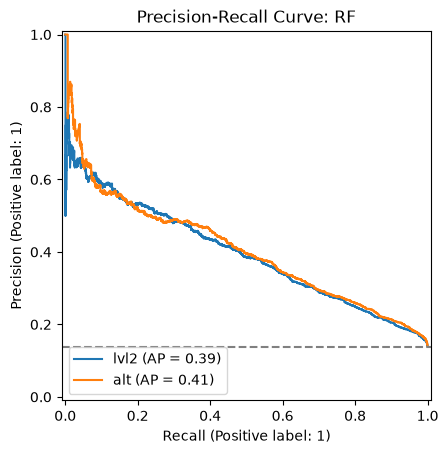

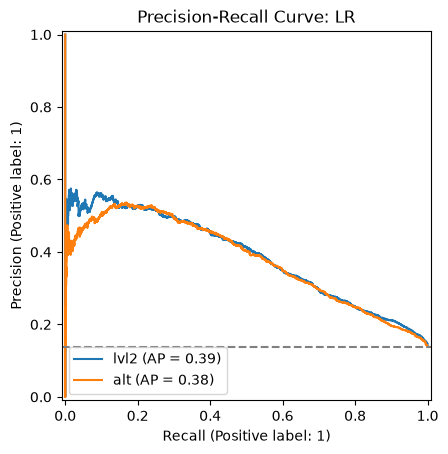

In [ ]:
'''
Precision-recall curve for both models together
'''

flat_test = {'lvl2': lvl2_flat_test, 'alt': alt_flat_test}
for model_name in ('RF', 'LR'):
    fig, ax = plt.subplots()
    for n in ('lvl2', 'alt'):
        best_M = results[model_name][n][0]
        y_true = Ys_test['los_7']            
        y_prob = best_M.predict_proba(flat_test[n])[:, 1]

        PrecisionRecallDisplay.from_predictions(y_true, y_prob, name = n, ax=ax)

    # baseline for random classifier
    prevalence = y_true.mean()
    ax.axhline(y=prevalence, color='grey', linestyle='--', label='Random Classifier')

    ax.set_title(f'Precision-Recall Curve: {model_name}')
    fig.savefig(PLOTS_DIR / f'au_prc_{model_name}_both_representations.png')


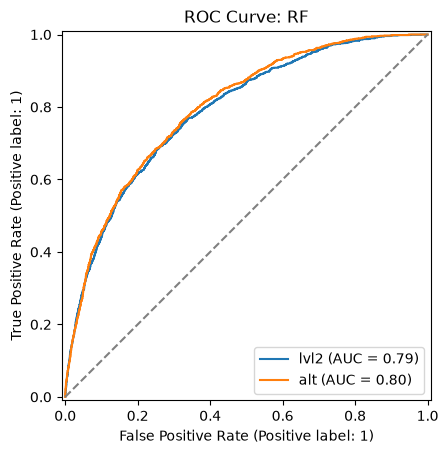

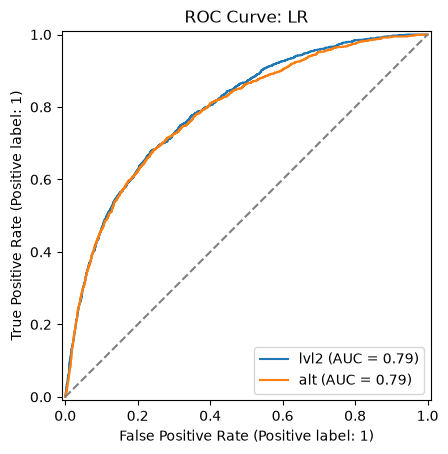

In [ ]:
'''AUC-ROC curve for both models together
'''

flat_test = {'lvl2': lvl2_flat_test, 'alt': alt_flat_test}
for model_name in ('RF', 'LR'):
    fig, ax = plt.subplots()
    for n in ('lvl2', 'alt'):
        best_M = results[model_name][n][0]
        y_true = Ys_test['los_7']            
        y_prob = best_M.predict_proba(flat_test[n])[:, 1]

        RocCurveDisplay.from_predictions(y_true, y_prob, name = n, ax=ax)

    # random classifier line
    ax.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random Classifier')

    ax.set_title(f'ROC Curve: {model_name}')
    fig.savefig(PLOTS_DIR / f'auc_roc_{model_name}_both_representations.png')


In [ ]:
'''
find optimum threshold for sensitivity/specificity based on F1 score
'''

#flat_dev = {'lvl2': lvl2_flat_dev, 'alt': alt_flat_dev}
flat_test = {'lvl2': lvl2_flat_test, 'alt': alt_flat_test}


best_thresholds = {}
for model_name in ('LR', 'RF'):
    for n in ('lvl2', 'alt'):
        best_M = results[model_name][n][0]
        y_true = Ys_test['los_7']
        y_prob = best_M.predict_proba(flat_test[n])[:, 1]

        precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
        print(precision)
        print(recall)
        print(thresholds)

        f1 = 2 * ((precision * recall) / (precision + recall + 1e-12)) # adding small addition to deal with zeros

        f1 = f1[:-1]  # remove last entry in array 
        f1idx = np.argmax(f1)
        print (f"Threshold for maximum F1 for {model_name}, {n}: {thresholds[f1idx]})")
        best_thresholds[(model_name, n)] = thresholds[f1idx]

[0.13887549 0.13888889 0.13890229 ... 0.         0.         1.        ]
[1. 1. 1. ... 0. 0. 0.]
[0.00160932 0.00317647 0.00722762 ... 0.85479381 0.85839509 0.86423886]
Threshold for maximum F1 for LR, lvl2: 0.20934133003457372)
[0.13887549 0.13888889 0.13890229 ... 0.         0.         1.        ]
[1. 1. 1. ... 0. 0. 0.]
[6.89260989e-05 3.93514367e-04 1.01121177e-03 ... 9.94269060e-01
 9.99863580e-01 9.99991494e-01]
Threshold for maximum F1 for LR, alt: 0.21203429998713139)
[0.13887549 0.13888889 0.13890229 ... 0.5        1.         1.        ]
[1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 6.94444444e-04
 6.94444444e-04 0.00000000e+00]
[0.00122448 0.00207958 0.00218743 ... 0.60930259 0.62265518 0.62692248]
Threshold for maximum F1 for RF, lvl2: 0.2207589479734664)
[0.13887549 0.13888889 0.13890229 ... 1.         1.         1.        ]
[1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 1.38888889e-03
 6.94444444e-04 0.00000000e+00]
[0.01320133 0.01322864 0.01327444 ... 0.5769046  0.

In [ ]:
'''
Generate confusion matrix with these thresholds
'''

flat_dev = {'lvl2': lvl2_flat_dev, 'alt': alt_flat_dev}
flat_test = {'lvl2': lvl2_flat_test, 'alt': alt_flat_test}


for model_name in ('RF', 'LR'):
    for n in ('lvl2', 'alt'):
        best_M = results[model_name][n][0]
        y_true = Ys_test['los_7']       
        #y_pred = best_M.predict(lvl2_flat_dev)  
        y_prob = best_M.predict_proba(flat_test[n])[:, 1]

        y_pred = (y_prob >= best_thresholds[(model_name, n)]).astype(float)  # using threshold extracted above

        label = f'{model_name}, {n}'

        # confusion matrix:
        matrix = ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
        matrix.ax_.set_title(f'Confusion Matrix: {label}')
        matrix.figure_.savefig(PLOTS_DIR / f'confusion_matrix_{model_name}_{n}.png')

In [ ]:
'''
get sensitivity, specificity, etc. based on the optimum thresholds
'''

metrics = {}

#flat_dev = {'lvl2': lvl2_flat_dev, 'alt': alt_flat_dev}
flat_test = {'lvl2': lvl2_flat_test, 'alt': alt_flat_test}

for model_name in ('RF', 'LR'):
    for n in ('lvl2', 'alt'):
        best_M = results[model_name][n][0]
        y_true = Ys_test['los_7']       
        #y_pred = best_M.predict(lvl2_flat_test)  
        y_prob = best_M.predict_proba(flat_test[n])[:, 1]
        y_pred = (y_prob >= best_thresholds[(model_name, n)]).astype(float)  # using threshold extracted above

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        sensitivity = tp / (tp + fn)    # same as recall. proportion of true positives correctly predicted
        specificity = tn / (tn + fp)    # proportion of true negatives correctly predicted
        precision = tp / (tp + fp)      # proportion of predicted positives that were correct
        f1 = 2 * ((precision * sensitivity) / (precision + sensitivity)) 

        metrics[(model_name, n)] = {
            'threshold': best_thresholds[(model_name, n)],
            'sensitivity': sensitivity,
            'specificity': specificity,
            'precision': precision,
            'F1': f1
        }
threshold_metrics = pd.DataFrame(metrics).T
print(threshold_metrics)
threshold_metrics.to_csv(TABLES_DIR / 'threshold_metrics.csv', index=False)



         threshold  sensitivity  specificity  precision        F1
RF lvl2   0.220759     0.538194     0.857655   0.378788  0.444636
   alt    0.205666     0.568056     0.846119   0.373175  0.450441
LR lvl2   0.209341     0.541667     0.864822   0.392552  0.455209
   alt    0.212034     0.536806     0.864598   0.390010  0.451783


In [ ]:
'''
Brier score
'''

brier_scores = {}
for model_name in ('RF', 'LR'):
    for n in ('lvl2', 'alt'):
        best_M = results[model_name][n][0]
        y_true = Ys_test['los_7']       
        y_prob = best_M.predict_proba(flat_test[n])[:, 1]

        brier_scores[(model_name, n)] = brier_score_loss(y_true, y_prob)
        print(f"Brier score for {model_name}, {n}: {brier_scores[(model_name, n)]}")

Brier score for RF, lvl2: 0.10161008821492562
Brier score for RF, alt: 0.10085140360334667
Brier score for LR, lvl2: 0.10096438768810041
Brier score for LR, alt: 0.10209103491415207


In [ ]:
'''
Feature importance (random forest models only)
'''

flat_test = {'lvl2': lvl2_flat_test, 'alt': alt_flat_test}


for n in ('lvl2', 'alt'):
    best_M = results['RF'][n][0]

    importances = pd.Series(best_M.feature_importances_, index = flat_test[n].columns).sort_values(ascending=False)
    print(f'RF, {n} - Feature importances:')
    print(importances.head(20))




RF, lvl2 - Feature importances:
variable     Aggregation Function      hours_in
mbp          hours_since_last_measure  24          0.004748
dbp          hours_since_last_measure  24          0.004617
             mask                      24          0.004169
sbp          hours_since_last_measure  23          0.003901
             mask                      24          0.003725
             hours_since_last_measure  24          0.003669
mbp          mask                      24          0.003529
calcium      hours_since_last_measure  8           0.003519
mbp          hours_since_last_measure  23          0.003487
calcium      hours_since_last_measure  10          0.003330
temperature  mean                      24          0.003304
sbp          mask                      23          0.003140
mbp          mask                      23          0.003131
dbp          hours_since_last_measure  23          0.003124
mbp          hours_since_last_measure  21          0.003108
resp_rate    mean   